<a href="https://colab.research.google.com/github/Zuzanna-Dedyk/Zuzanna-Dedyk.github.io/blob/main/tDCS_model_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
=============================================================
BAYESIAN ANALYSIS OF IPS NEUROMODULATION DURING COFFEE FLAVOUR PERCEPTION
=============================================================
Project : Bayesian Brain, Predictive Coding and Flavour Perception
Author  : Zuzanna Dedyk
Cleaned : August 2026 (attempt 1 -- baseline univariate-outcome pipeline)

-------------------------------------------------------------
1. RESEARCH QUESTION
-------------------------------------------------------------
Does anodal tDCS over bilateral intraparietal sulcus (IPS) alter how strongly
participants weight learned priors (coffee origin / familiarity) when they
rate the sensory and hedonic properties of a coffee, and does this weighting
change with serving temperature?

This follows a predictive-coding framing of flavour perception: perceived
flavour is a combination of bottom-up sensory input (temperature, chemical
composition) and top-down priors (expectations built from prior experience
with a coffee's origin). IPS is implicated in combining/weighting priors and
sensory evidence, so stimulating it is hypothesised to shift that balance.

-------------------------------------------------------------
2. HYPOTHESES
-------------------------------------------------------------
H1 (Stimulation x Familiarity):
    Active IPS stimulation will change ratings differently for the familiar
    coffee (Brazil) than for the unfamiliar coffee (Kenya), relative to sham
    -- i.e. a non-zero beta_stim_fam interaction. Direction: because
    stimulation is hypothesised to *down-weight priors relative to sensory
    input*, we expect stimulation to move unfamiliar-coffee ratings less (or
    in the opposite direction) than familiar-coffee ratings.

H2 (Stimulation x Temperature):
    The effect of stimulation will vary with serving temperature (beta_stim_warm,
    beta_stim_cold), since temperature changes the salience/reliability of the
    bottom-up sensory signal.

H3 (three-way Stimulation x Familiarity x Temperature):
    The Stimulation x Familiarity interaction (H1) itself depends on
    temperature -- tested by beta_threeway_warm / beta_threeway_cold.

H0 for all of the above: the relevant interaction coefficient's 95% credible
interval includes 0 / P(beta > 0) is not extreme (e.g. not > 0.95 or < 0.05).

These hypotheses are tested once per outcome variable (Section 8), since each
rating scale (flavour, balance, acidity, etc.) is modelled separately in this
first-pass pipeline. See the closing note in Section 10 for how this could be
extended to a joint multivariate model.

-------------------------------------------------------------
3. DESIGN SUMMARY
-------------------------------------------------------------
    Participant (random intercept, random stim slope)
        |
    Stimulation:  Sham  vs  Active tDCS               [within-subject]
        |
    Coffee:       Brazil (familiar) vs Kenya (unfamiliar)  [within-subject]
        |
    Repeated rating: 1 = Hot (~60C), 2 = Warm (~50C), 3 = Cold (~30C)

Observations are nested within participants (repeated ratings of the same
coffee at different temperatures, under both stimulation conditions), so a
hierarchical (multilevel) model is used with random intercepts for subject,
coffee, and "tasting episode" (a specific subject x condition x coffee visit),
plus a random by-subject slope for the stimulation effect.

-------------------------------------------------------------
4. VARIABLE GLOSSARY
-------------------------------------------------------------
Raw column (as exported)   -> Cleaned name         -> Meaning / coding
-------------------------------------------------------------
subject                    -> subject               Participant ID (categorical)
group                       -> counterbalance        Counterbalance arm A/B/C/D;
                                                      determines which physical
                                                      coffee batch (Brazil_1/2,
                                                      Kenya_1/2) each label maps to
coffee                      -> coffee                Nominal label shown to
                                                      participant: "Brasil"/"Kenya"
condition                   -> condition             tDCS condition: "sham" /
                                                      "stimulation"
temperature                 -> temperature           Measured serving temp (C)
repeated_ratings             (kept as-is)            Rating occasion: 1/2/3, maps
                                                      to Hot/Warm/Cold (see below)
acidityintens               -> acidity_intensity     Perceived acidity intensity
bodylvl                     -> body_intensity        Perceived body/mouthfeel
                                                      intensity
notesaroma                  -> aroma_notes            Free-text / coded aroma notes
"bitter,_roasted"           -> negative_notes          Coded negative flavour notes

Derived columns (created in this script):
-------------------------------------------------------------
temperature_level          Hot/Warm/Cold, thresholded from measured `temperature`
                            (>=55 Hot, >=45 Warm, else Cold). Used only for
                            sanity-checking against the *nominal* rating order
                            (repeated_ratings), not fed to the model.
temperature_stage          Hot/Warm/Cold, derived directly from repeated_ratings
                            (1/2/3). This is the nominal experimental factor
                            actually used for grouping/plots.
familiarity                 "Familiar" (Brazil) / "Unfamiliar" (Kenya) -- the
                            experimental proxy for "has a learned prior about
                            this coffee"
coffee_id                   Physical coffee batch identity (Brazil_1/2, Kenya_1/2)
                            recovered from the `counterbalance` group, so that
                            random effects reflect the actual physical stimulus,
                            not just the label
origin                      Brazil / Kenya (English spelling of `coffee`)
participant_idx, coffee_idx, tasting_idx
                            1-indexed integer codes required by Stan (Stan does
                            not accept category/string indices directly)
tasting_id / tasting_idx     Identifier for a subject x condition x coffee
                            "tasting episode" (a participant tastes the same
                            physical coffee up to 3 times, at 3 temperatures,
                            within one condition -- this groups those 3 ratings)
stim_idx                    0 = sham, 1 = active stimulation (model predictor)
fam_idx                     0 = Familiar, 1 = Unfamiliar (model predictor)
temp_warm, temp_cold         Dummy-coded temperature (Hot is the reference level)

Outcome variables (rating scales, all on the study's Likert/VAS scale):
-------------------------------------------------------------
fragrance, flavour, aftertaste, acidity, body, balance, sweetness,
acidity_intensity, body_intensity, overall (= overall hedonic liking)

-------------------------------------------------------------
5. WHAT WAS CHANGED FROM THE ORIGINAL AI-GENERATED NOTEBOOK
-------------------------------------------------------------
- Removed duplicate/redundant cells: repeated imports, a defensive block that
  recomputed columns already created earlier ("From <cell-id>" patches),
  and near-identical copy-pasted plotting blocks for each outcome (replaced
  with reusable functions called in a loop).
- Fixed a real bug: `az.extract(idata)` and the resulting posterior-prediction
  section were originally called *before* `idata = az.from_cmdstanpy(fit)`
  existed. `idata` construction now happens immediately after sampling.
- Removed the single hardcoded `OUTCOME = "balance"` and replaced it with a
  loop over all outcomes you listed (flavour, aftertaste, acidity, sweetness,
  balance, body, acidity_intensity, body_intensity, overall), so the whole
  pipeline (fit, diagnostics, contrasts, plots) runs once per outcome and
  results are collected into one comparison table.
- Added `drop_empty_columns()` to remove fully-empty columns automatically
  (safer than hardcoding column names, since I don't have your raw file here
  to inspect).
- Consolidated the three copies of index-creation code (participant_idx,
  coffee_idx, tasting_idx, stim_idx, fam_idx, temp_warm/cold) into one place.
- Added comments throughout explaining *why* each step happens, not just what
  it does, and flagged the hardcoded "overall < 6 = error" data-cleaning rule
  so you can double check that threshold still makes sense (see Section 6).
"""

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Publication-quality figure defaults
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["font.size"] = 11

np.random.seed(42)  # reproducibility for any stochastic plotting/sampling steps

print("Environment loaded.")

Environment loaded.


In [2]:
# ==============================================================================
# 1. LOAD DATA
# ==============================================================================

DATA_PATH = "/content/Copy of tDCS coffee tasting study results_March23.xlsx - Longlist exp (2)-2.csv"
df = pd.read_csv(DATA_PATH)
print(f"Raw data shape: {df.shape}")

Raw data shape: (408, 42)


In [3]:
# ==============================================================================
# 2. CLEAN COLUMN NAMES AND DTYPES
# ==============================================================================

# Normalise column names: strip whitespace, lowercase, spaces -> underscores
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename the columns whose raw names are unclear / inconsistent
df = df.rename(columns={
    "acidityintens": "acidity_intensity",
    "bodylvl": "body_intensity",
    "notesaroma": "aroma_notes",
    "bitter,_roasted": "negative_notes",
    "group": "counterbalance",
})


def drop_empty_columns(data: pd.DataFrame) -> pd.DataFrame:
    """Remove columns that are entirely missing (no participant ever filled
    them in). Safer than hardcoding column names since empty columns can
    differ between export batches."""
    empty_cols = data.columns[data.isna().all()].tolist()
    if empty_cols:
        print(f"Dropping {len(empty_cols)} fully-empty column(s): {empty_cols}")
    return data.drop(columns=empty_cols)


df = drop_empty_columns(df)

# Set categorical dtypes for identifiers / grouping variables
for col in ["subject", "counterbalance", "coffee", "condition"]:
    df[col] = df[col].astype("category")

df["condition"] = df["condition"].astype(str).str.strip().astype("category")

df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")

# Temperature bucketed from the *measured* temperature -- used only as a
# sanity check against the nominal rating order (see Section 3 QC).
df["temperature_level"] = pd.Categorical(
    np.where(df["temperature"] >= 55, "Hot",
             np.where(df["temperature"] >= 45, "Warm", "Cold")),
    categories=["Hot", "Warm", "Cold"],
    ordered=True,
)

# Coerce all rating scales to numeric (some exports store these as text)
RATING_COLUMNS = [
    "fragrance", "flavour", "aftertaste", "acidity", "body", "balance",
    "sweetness", "acidity_intensity", "body_intensity", "overall",
]
for col in RATING_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        print(f"NOTE: expected rating column '{col}' not found in the data -- check spelling in the raw file.")

Dropping 22 fully-empty column(s): ['unnamed:_19', 'unnamed:_20', 'unnamed:_21', 'unnamed:_22', 'unnamed:_23', 'unnamed:_24', 'unnamed:_25', 'unnamed:_26', 'unnamed:_27', 'unnamed:_28', 'unnamed:_29', 'unnamed:_30', 'unnamed:_31', 'unnamed:_32', 'unnamed:_33', 'unnamed:_34', 'unnamed:_35', 'unnamed:_36', 'unnamed:_37', 'unnamed:_38', 'unnamed:_39', 'unnamed:_40']


In [4]:
# ==============================================================================
# 3. DATA QUALITY CHECKS
# ==============================================================================

print("\n" + "=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

missing = df.isna().sum().sort_values(ascending=False)
print("Missing values per column (top 10):")
print(missing.head(10))

n_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {n_duplicates}")

print("\nRatings per participant (should be balanced across the design):")
print(df.groupby("subject").size().describe())

print("\nRatings per subject x condition x coffee cell "
      "(should mostly be 3, one per temperature):")
print(df.groupby(["subject", "condition", "coffee"]).size().value_counts())


# ------------------------------------------------------------------------------
# Data-cleaning rule: treat 'overall' liking < 6 as a data-entry error.
# NOTE: this threshold was set in the original notebook without a stated
# justification -- confirm it matches your actual scale (e.g. if 'overall' is
# on a 1-9 hedonic scale, "<6" removes more than half the plausible range).
# Re-check this before trusting downstream results.
# ------------------------------------------------------------------------------
problematic = df[df["overall"] < 6]
if not problematic.empty:
    print(f"\n{len(problematic)} rows have 'overall' < 6 -- recoded to NaN:")
    print(problematic[["subject", "coffee", "condition", "repeated_ratings", "overall"]])
    df.loc[df["overall"] < 6, "overall"] = np.nan
else:
    print("\nNo 'overall' liking values below 6.")


DATA QUALITY CHECKS
Missing values per column (top 10):
unnamed:_41          400
body_intensity        11
negative_notes         9
acidity                8
sweetness              3
overall                3
body                   2
acidity_intensity      2
aftertaste             1
subject                0
dtype: int64

Duplicate rows: 0

Ratings per participant (should be balanced across the design):
count    34.0
mean     12.0
std       0.0
min      12.0
25%      12.0
50%      12.0
75%      12.0
max      12.0
dtype: float64

Ratings per subject x condition x coffee cell (should mostly be 3, one per temperature):
3    136
Name: count, dtype: int64

1 rows have 'overall' < 6 -- recoded to NaN:
   subject  coffee condition  repeated_ratings  overall
45    s004  Brasil      sham                 1      2.0


In [5]:
# ==============================================================================
# 4. FEATURE ENGINEERING
# ==============================================================================

# --- Nominal temperature stage, derived from the rating *order* (not the
#     measured temperature). This is the factor actually used in the model,
#     since it reflects the experimental manipulation exactly as designed.
TEMPERATURE_LABELS = {1: "Hot", 2: "Warm", 3: "Cold"}
df["temperature_stage"] = pd.Categorical(
    df["repeated_ratings"].map(TEMPERATURE_LABELS),
    categories=["Hot", "Warm", "Cold"],
    ordered=True,
)

# --- Familiarity: experimental proxy for "has a learned prior about this
#     coffee". Brazil is the familiar/local-market coffee, Kenya is unfamiliar.
df["origin"] = df["coffee"].replace({"Brasil": "Brazil", "Kenya": "Kenya"})
df["familiarity"] = pd.Categorical(
    df["origin"].replace({"Brazil": "Familiar", "Kenya": "Unfamiliar"}),
    categories=["Familiar", "Unfamiliar"],
    ordered=True,
)

# --- Decode counterbalancing: the label "Brasil"/"Kenya" a participant saw
#     maps to different *physical* coffee batches depending on their
#     counterbalance arm. Recovering the physical batch matters if you want
#     random effects (or QC) to reflect the actual stimulus rather than the
#     cover label.
COFFEE_LOOKUP = {
    "A": {"Brasil": "Brazil_1", "Kenya": "Kenya_1"},
    "B": {"Brasil": "Brazil_1", "Kenya": "Kenya_2"},
    "C": {"Brasil": "Brazil_2", "Kenya": "Kenya_1"},
    "D": {"Brasil": "Brazil_2", "Kenya": "Kenya_2"},
}
df["coffee_id"] = df.apply(
    lambda row: COFFEE_LOOKUP[row["counterbalance"]][row["coffee"]], axis=1
).astype("category")

print("\nCounterbalance x physical coffee batch crosstab:")
print(pd.crosstab(df["counterbalance"], df["coffee_id"]))

# --- Integer indices required by Stan (1-indexed; Stan cannot use
#     category/string labels directly).
analysis_df = df.copy()
analysis_df["participant_idx"] = analysis_df["subject"].astype("category").cat.codes + 1
analysis_df["coffee_idx"] = analysis_df["coffee_id"].astype("category").cat.codes + 1

# "Tasting episode" = one subject visiting one condition with one coffee
# (across up to 3 temperature ratings). Random intercept for this captures
# any episode-specific noise beyond subject/coffee main effects.
analysis_df["tasting_id"] = (
    analysis_df["subject"].astype(str) + "_"
    + analysis_df["condition"].astype(str) + "_"
    + analysis_df["coffee"].astype(str)
)
analysis_df["tasting_idx"] = analysis_df["tasting_id"].astype("category").cat.codes + 1

# Model predictors, dummy/zero-one coded for direct use in the Stan model
analysis_df["stim_idx"] = analysis_df["condition"].map({"sham": 0, "stimulation": 1})
analysis_df["fam_idx"] = analysis_df["familiarity"].map({"Familiar": 0, "Unfamiliar": 1})
analysis_df["temp_warm"] = (analysis_df["repeated_ratings"] == 2).astype(int)
analysis_df["temp_cold"] = (analysis_df["repeated_ratings"] == 3).astype(int)

print(f"\nParticipants: {analysis_df['subject'].nunique()}")
print(f"Observations: {len(analysis_df)}")
print(f"Tasting episodes: {analysis_df['tasting_idx'].nunique()}")
print(f"Coffees (physical batches): {analysis_df['coffee'].unique().tolist()}")
print(f"Conditions: {analysis_df['condition'].unique().tolist()}")


Counterbalance x physical coffee batch crosstab:
coffee_id       Brazil_1  Brazil_2  Kenya_1  Kenya_2
counterbalance                                      
A                     48         0       48        0
B                     42         0        0       42
C                      0        42       42        0
D                      0        72        0       72

Participants: 34
Observations: 408
Tasting episodes: 136
Coffees (physical batches): ['Brasil', 'Kenya']
Conditions: ['stimulation', 'sham']



Outcomes to be modelled: ['flavour', 'aftertaste', 'sweetness', 'balance', 'body', 'acidity_intensity', 'body_intensity', 'overall']


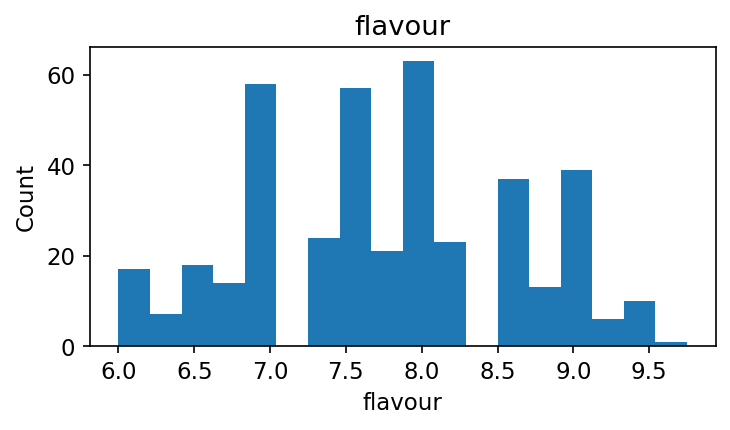

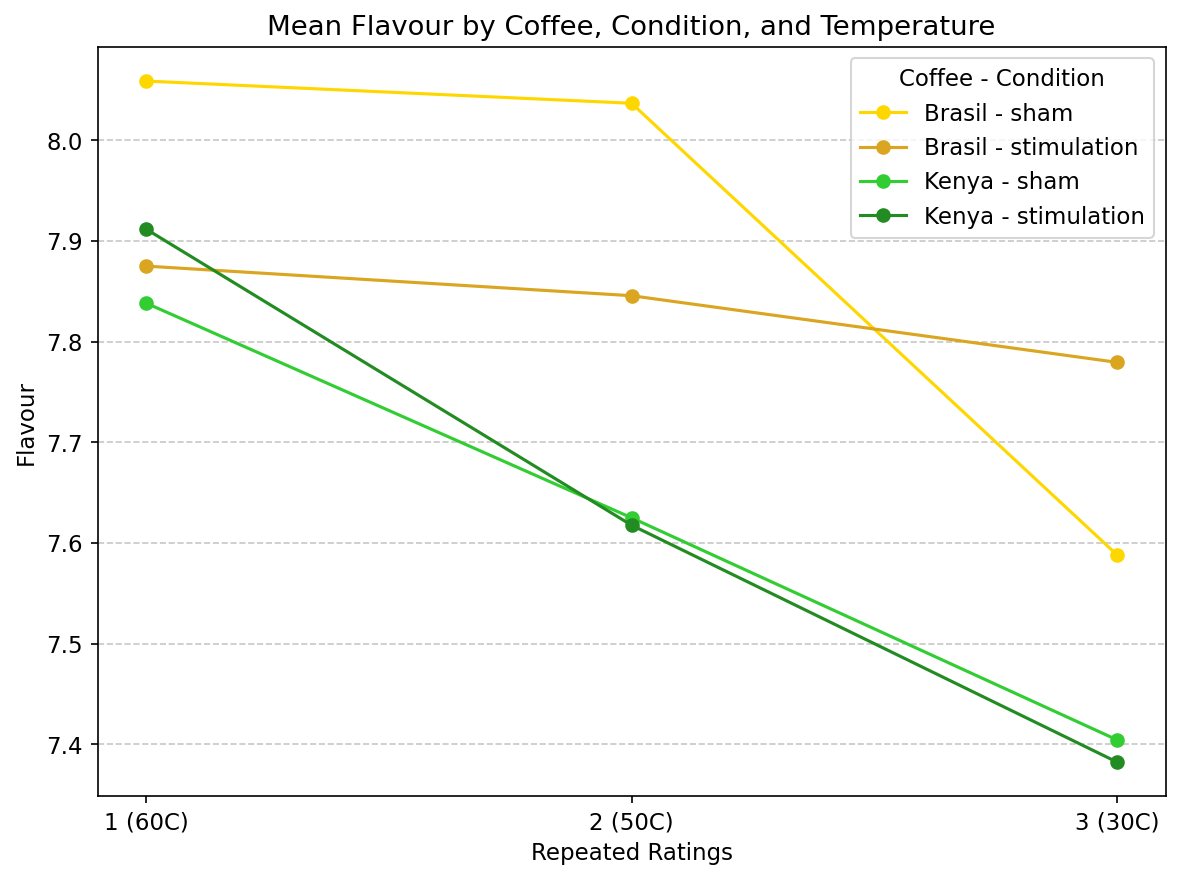

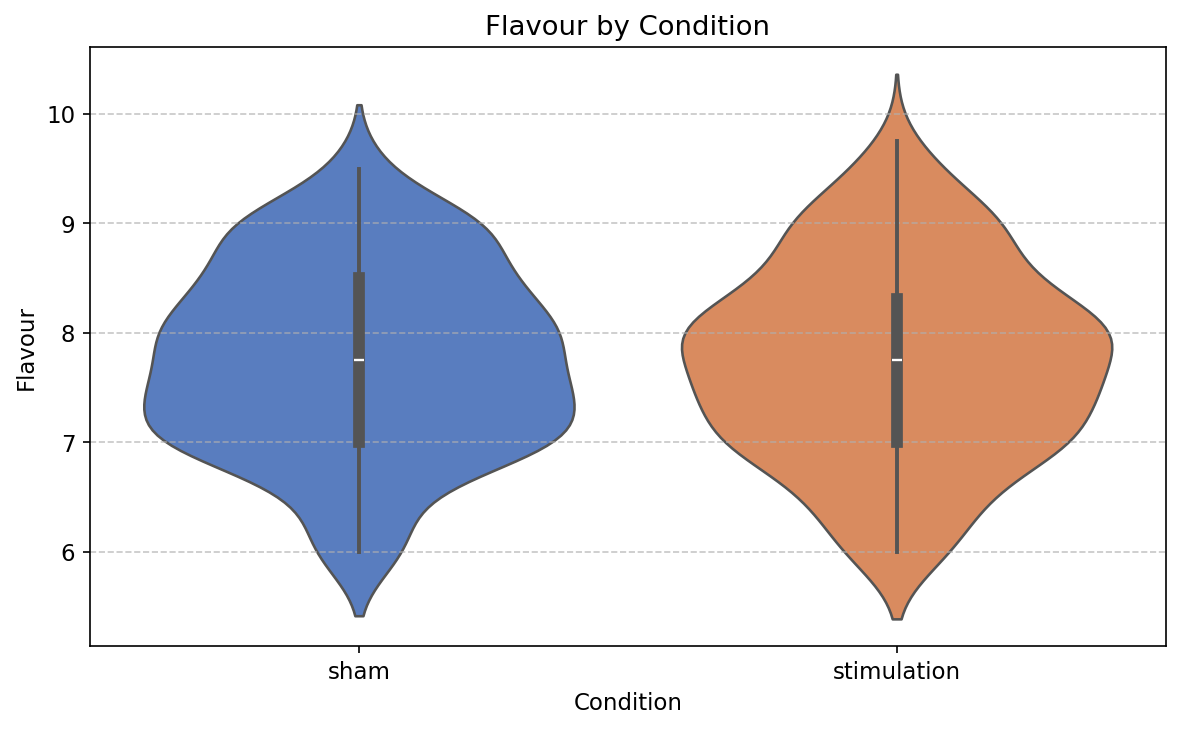

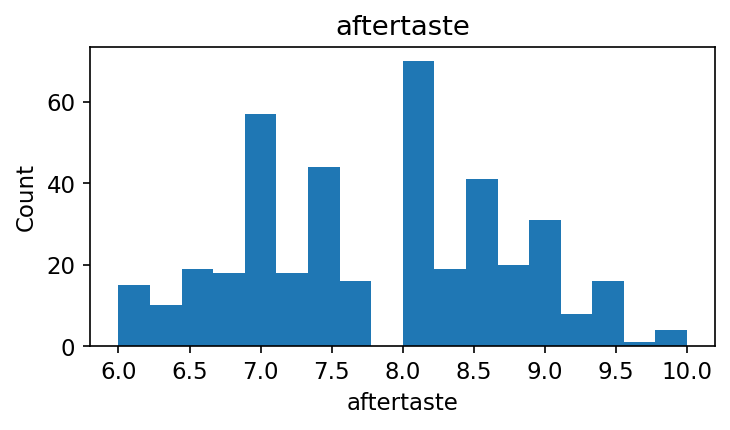

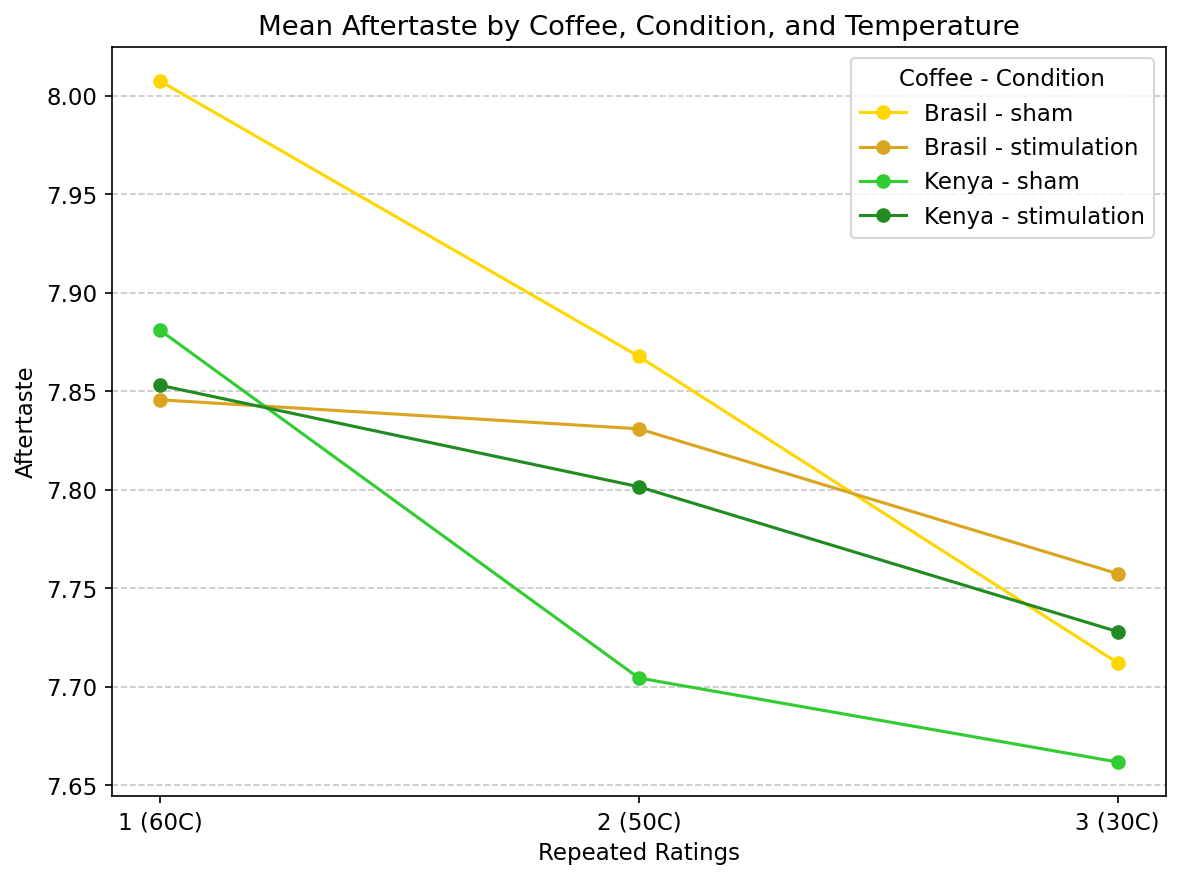

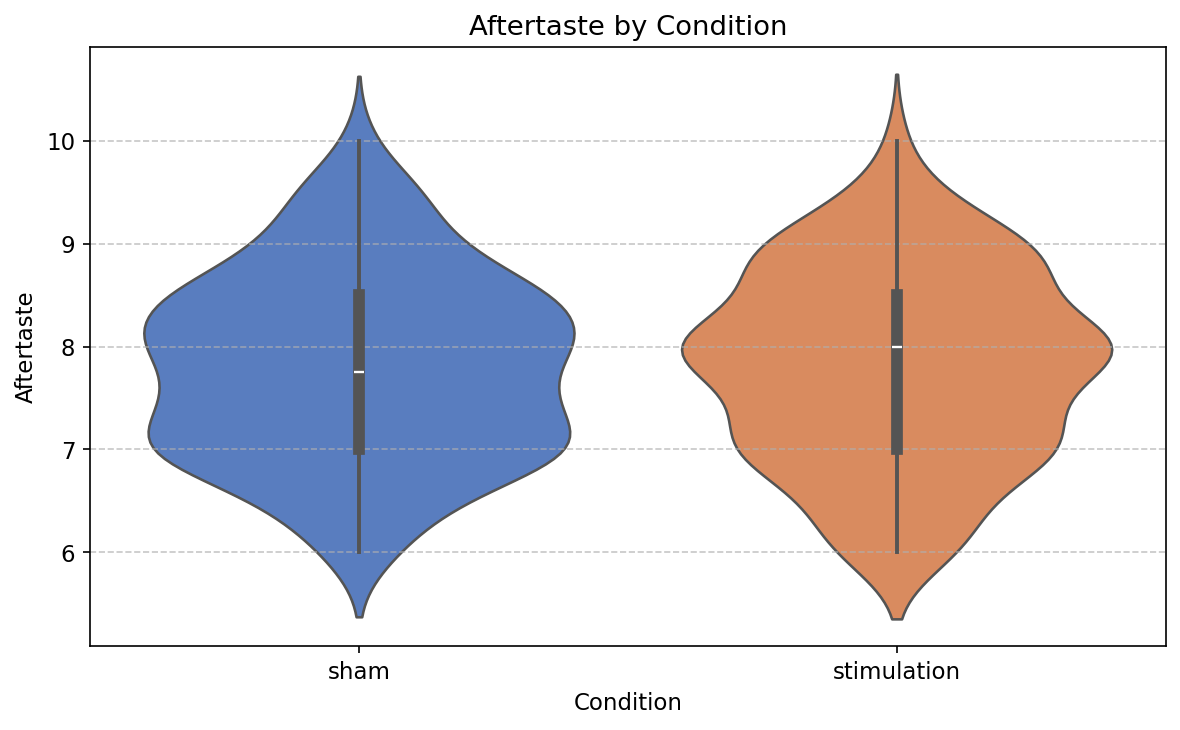

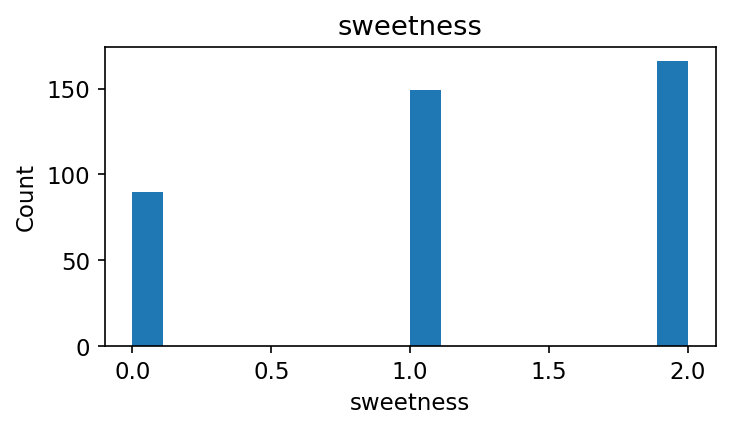

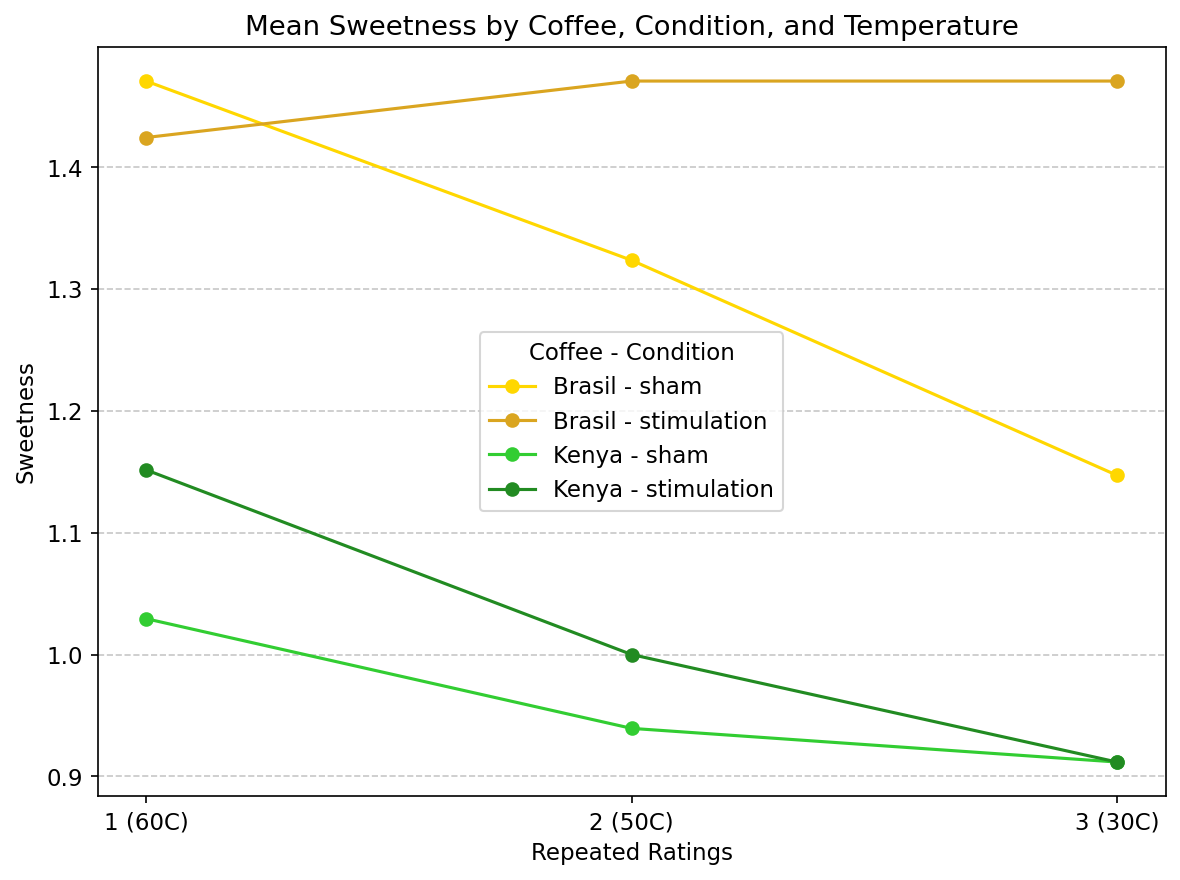

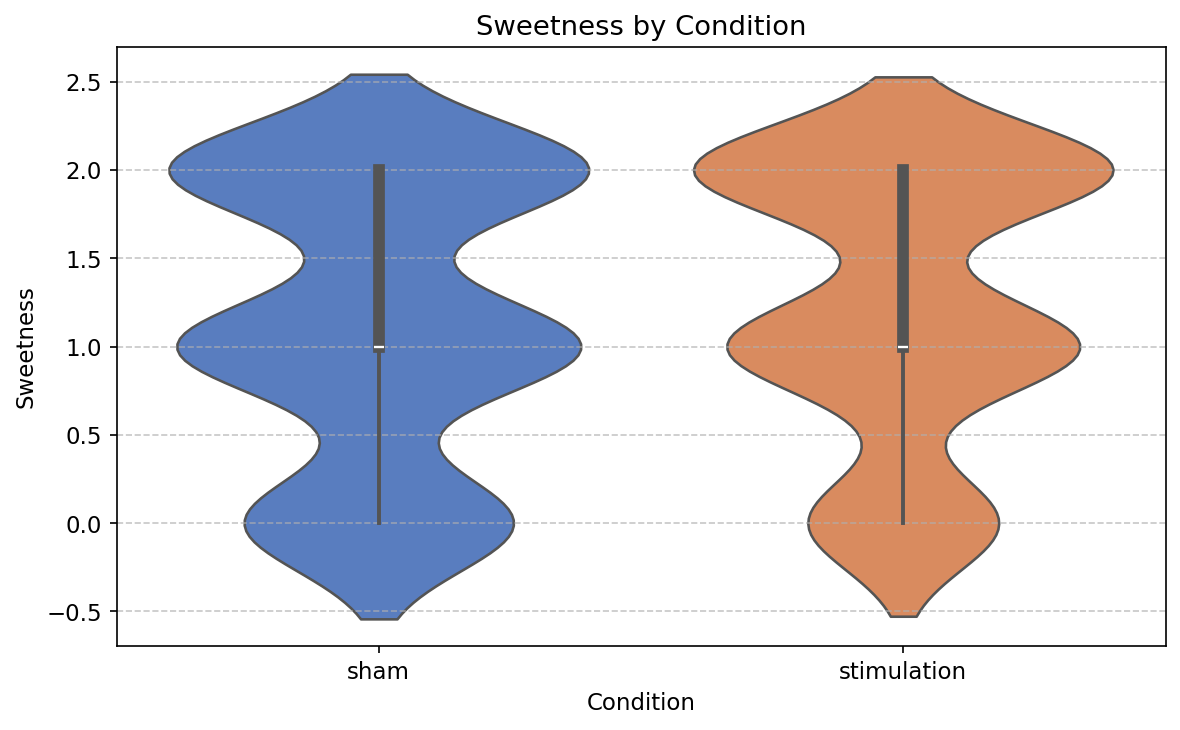

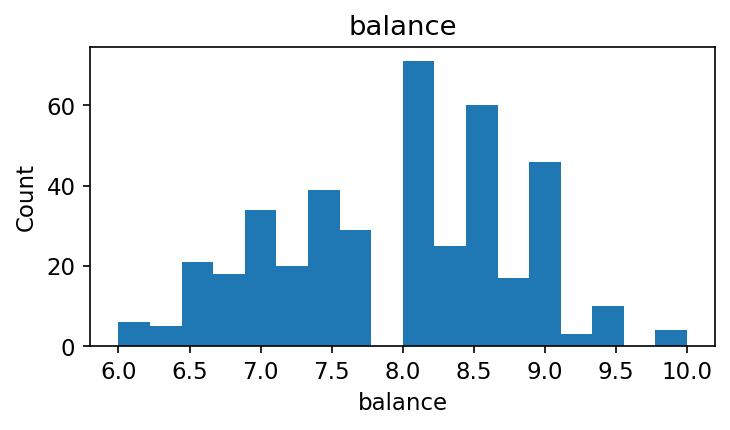

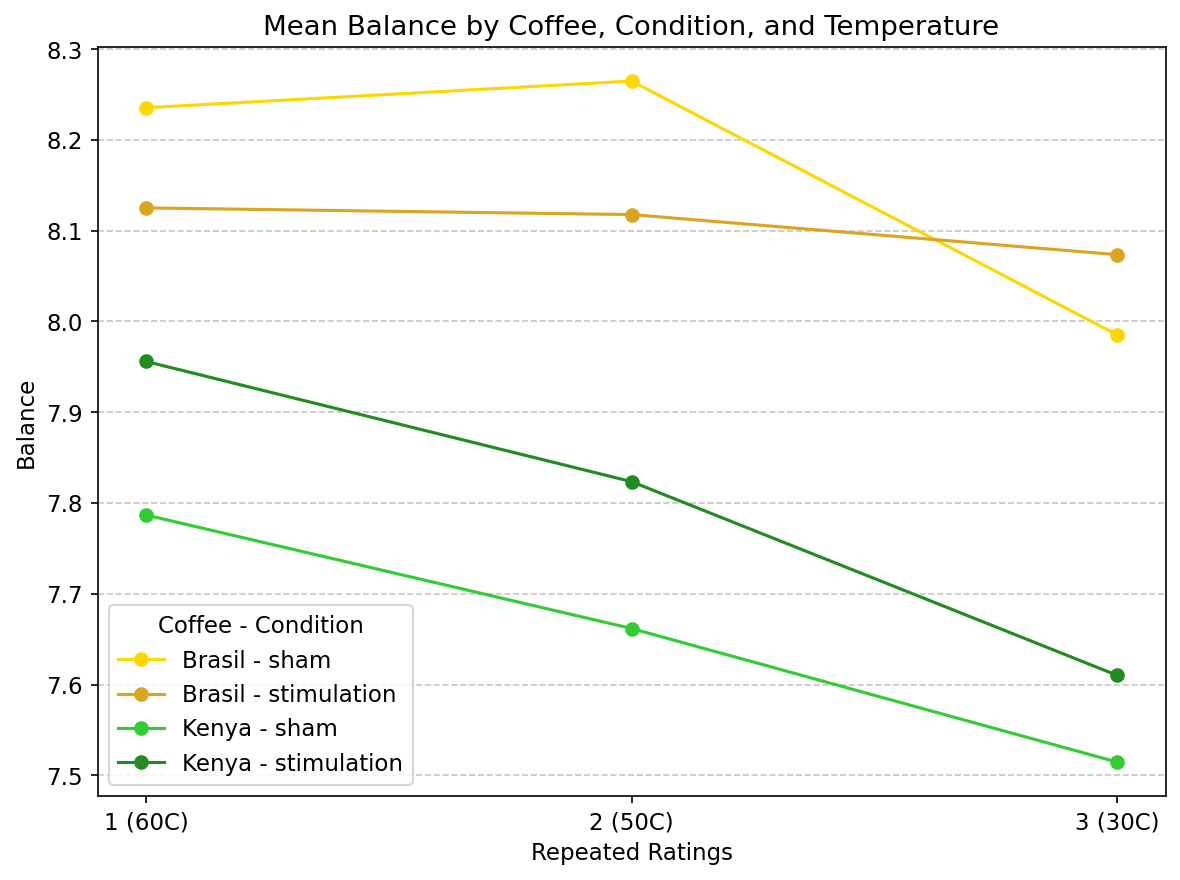

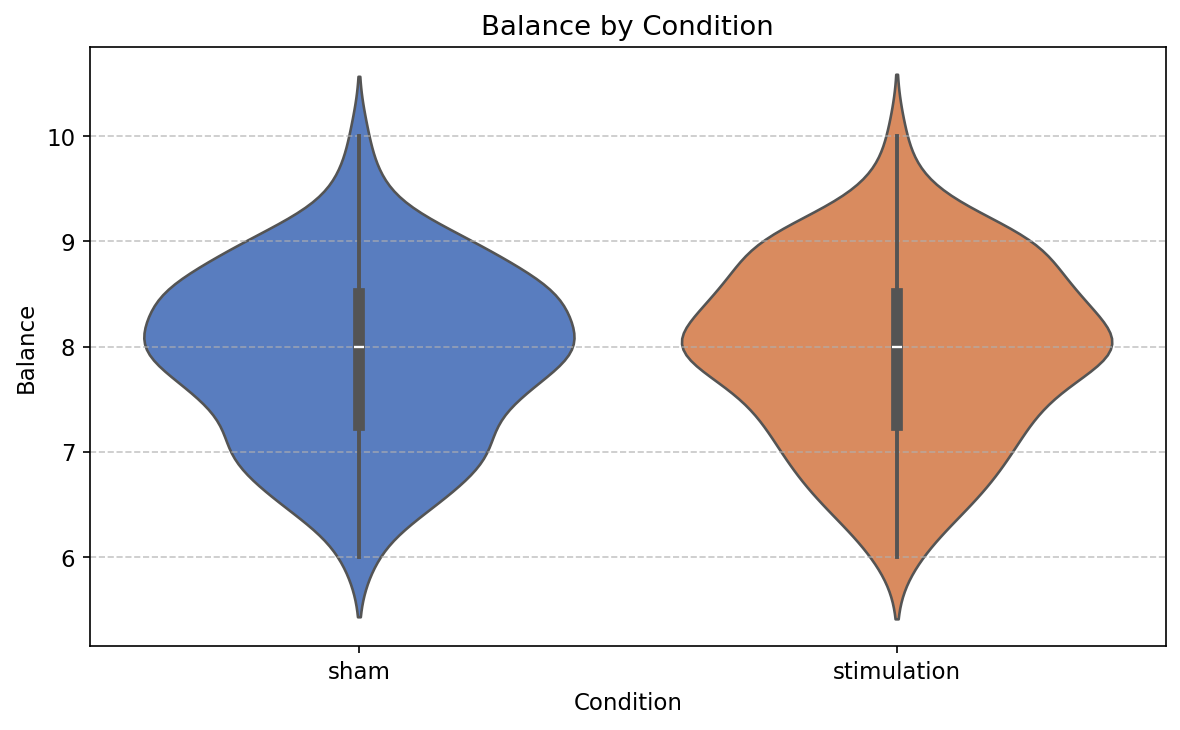

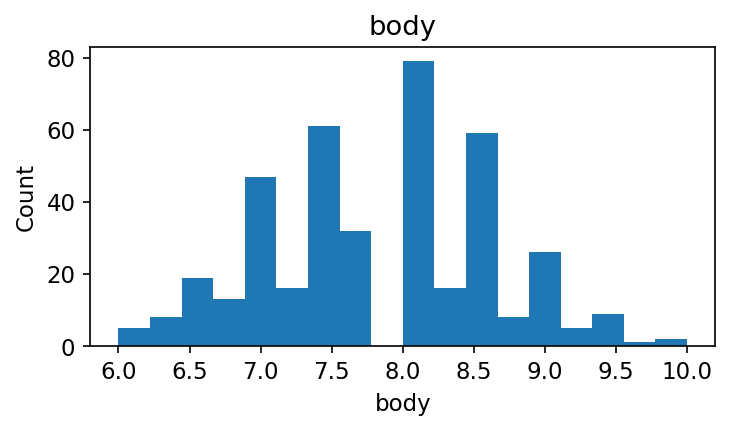

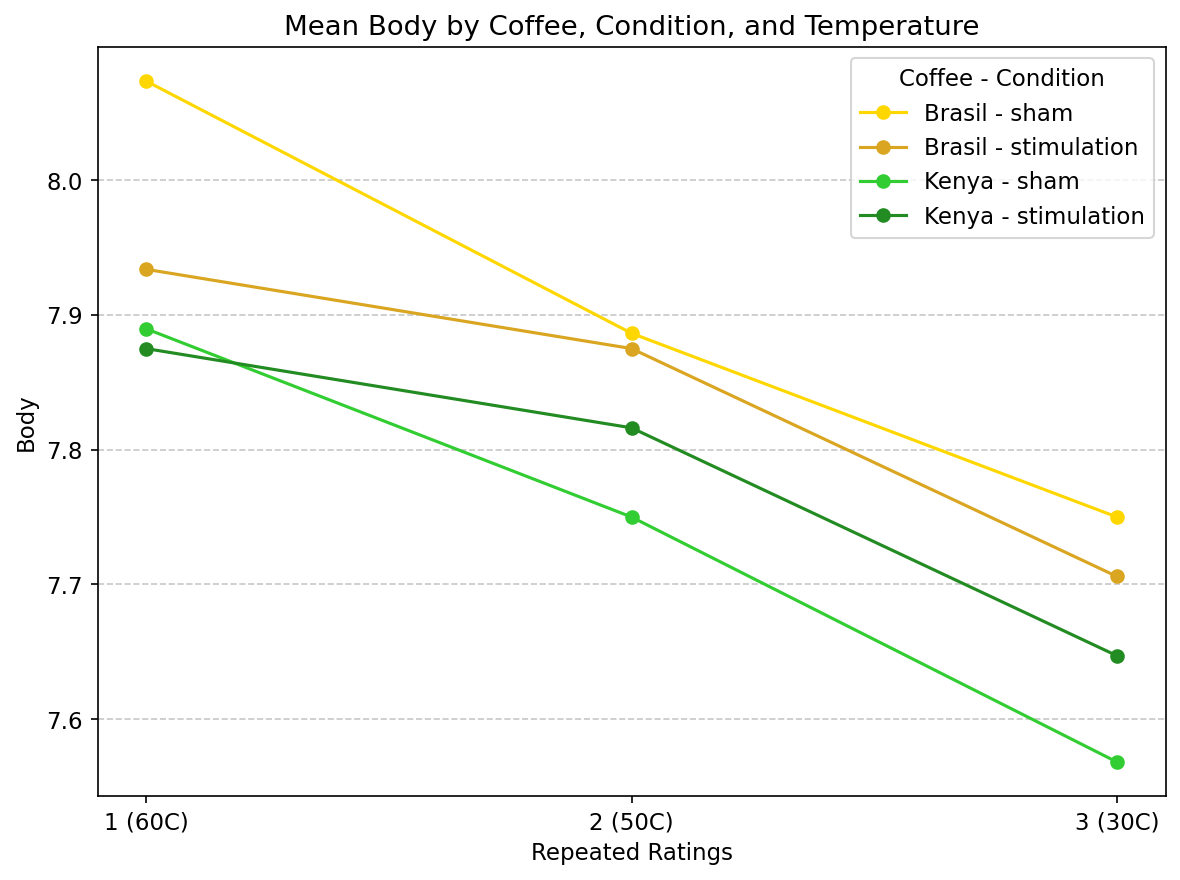

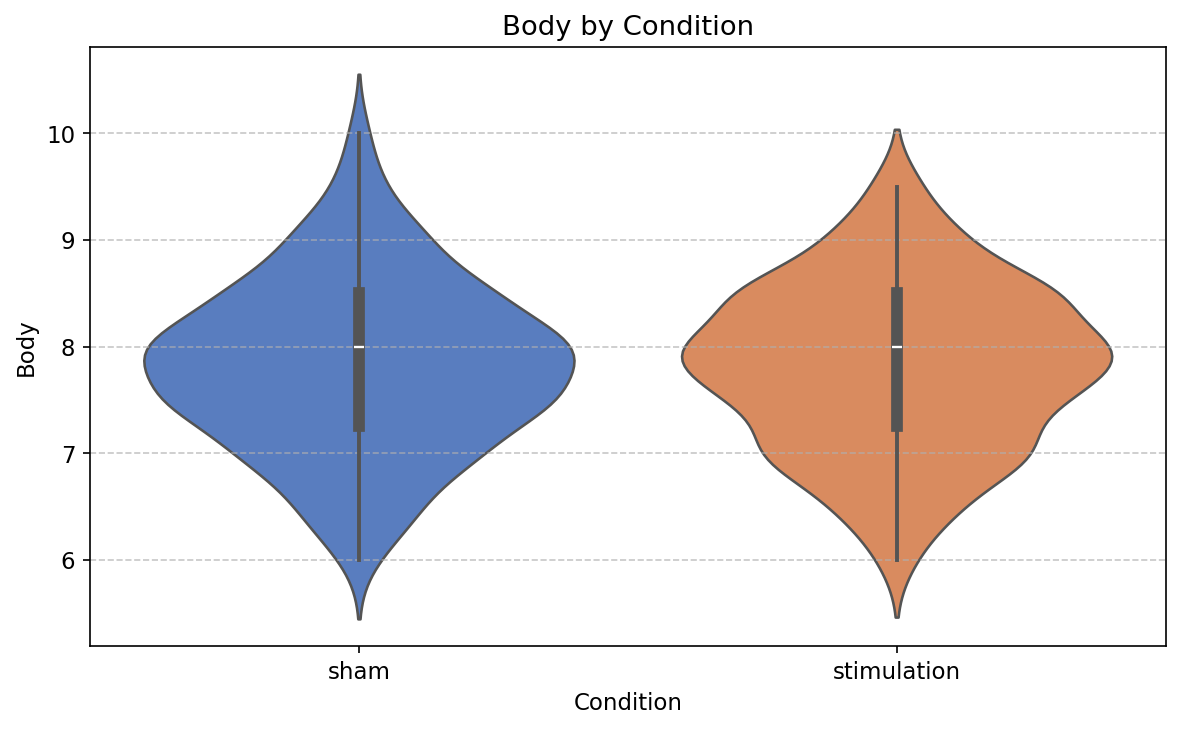

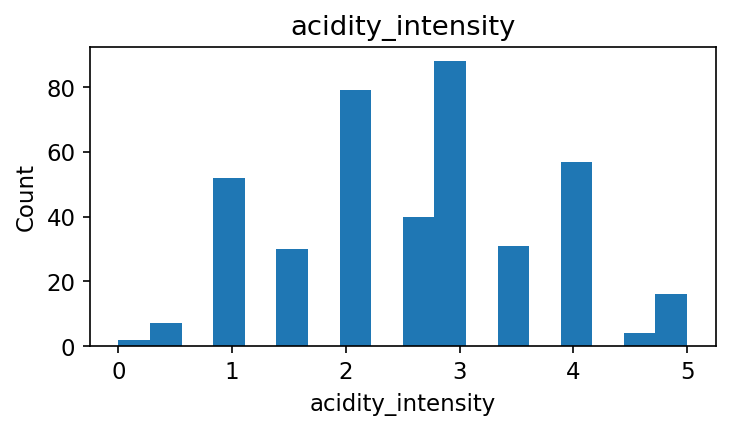

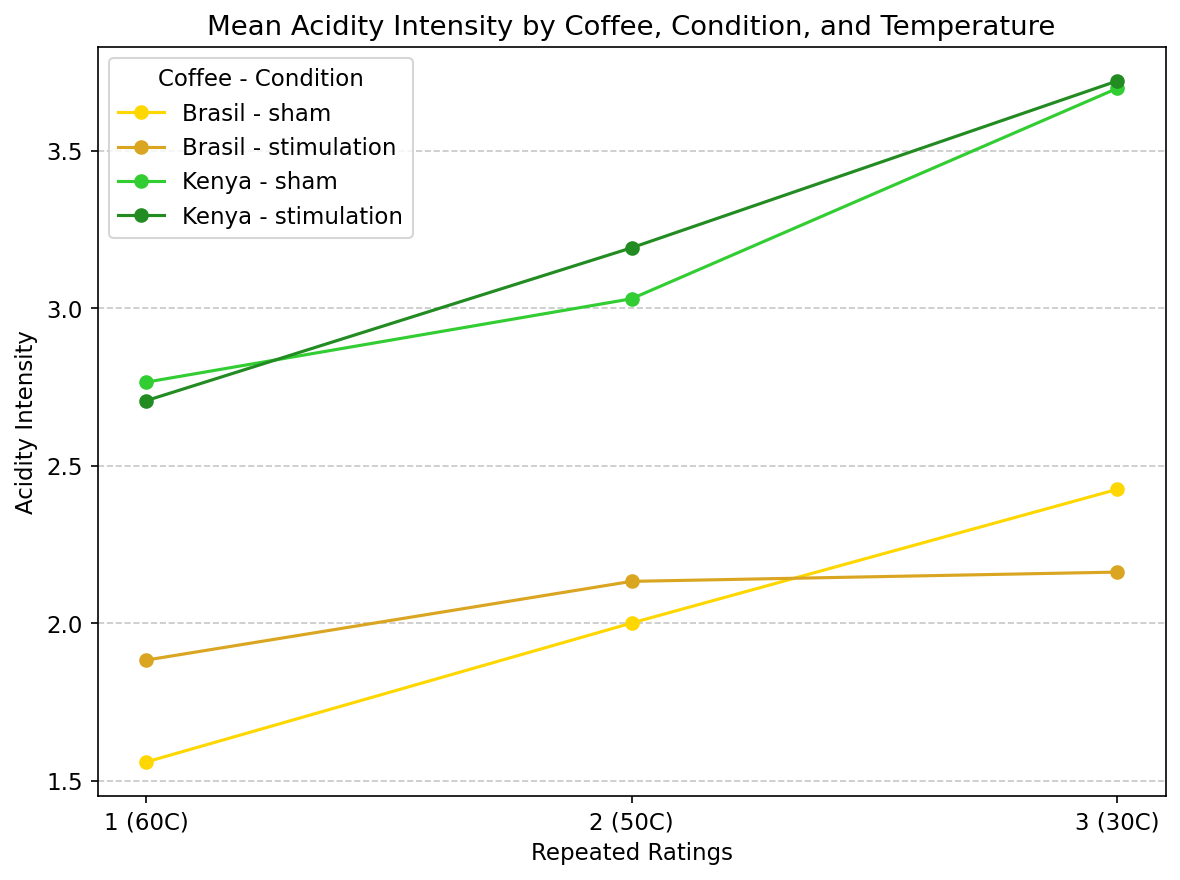

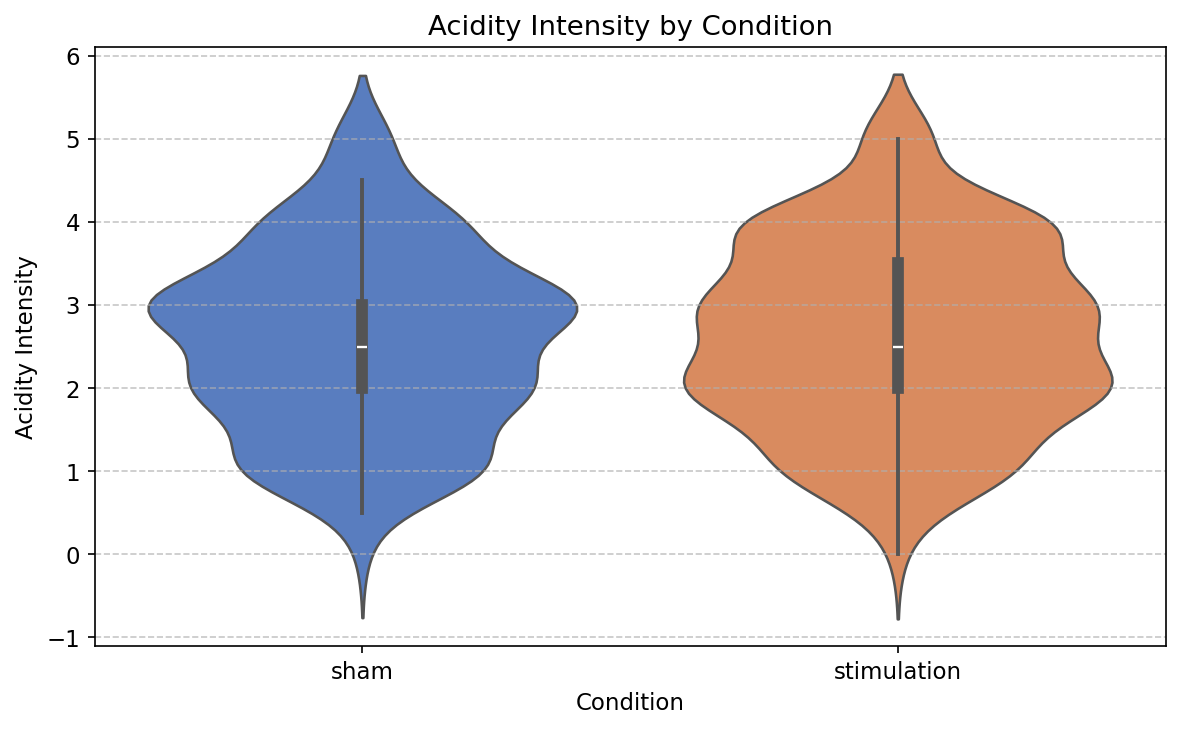

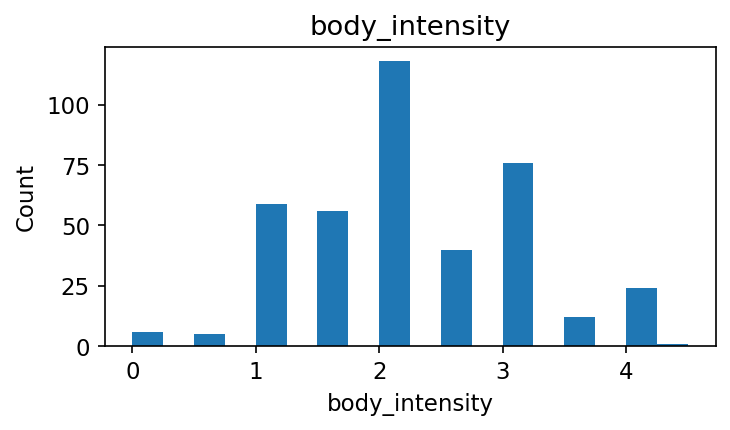

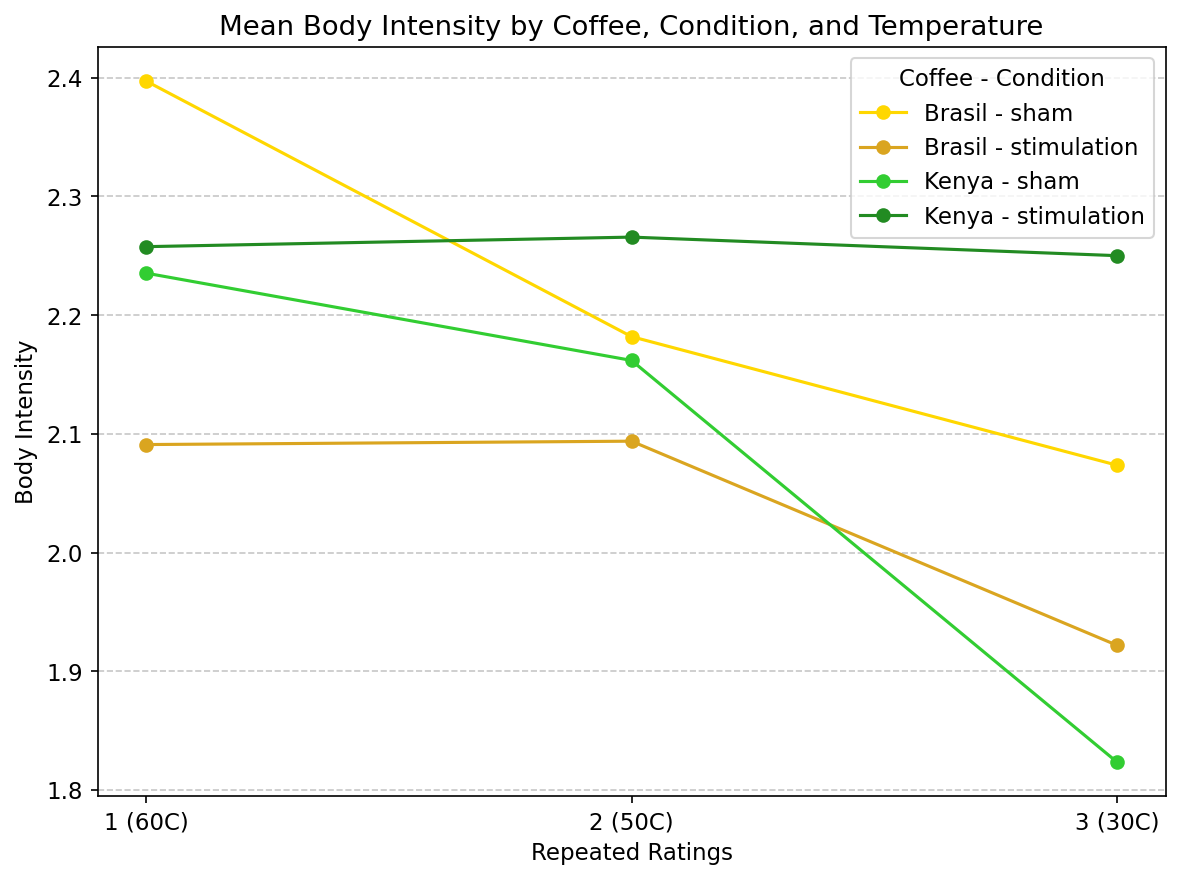

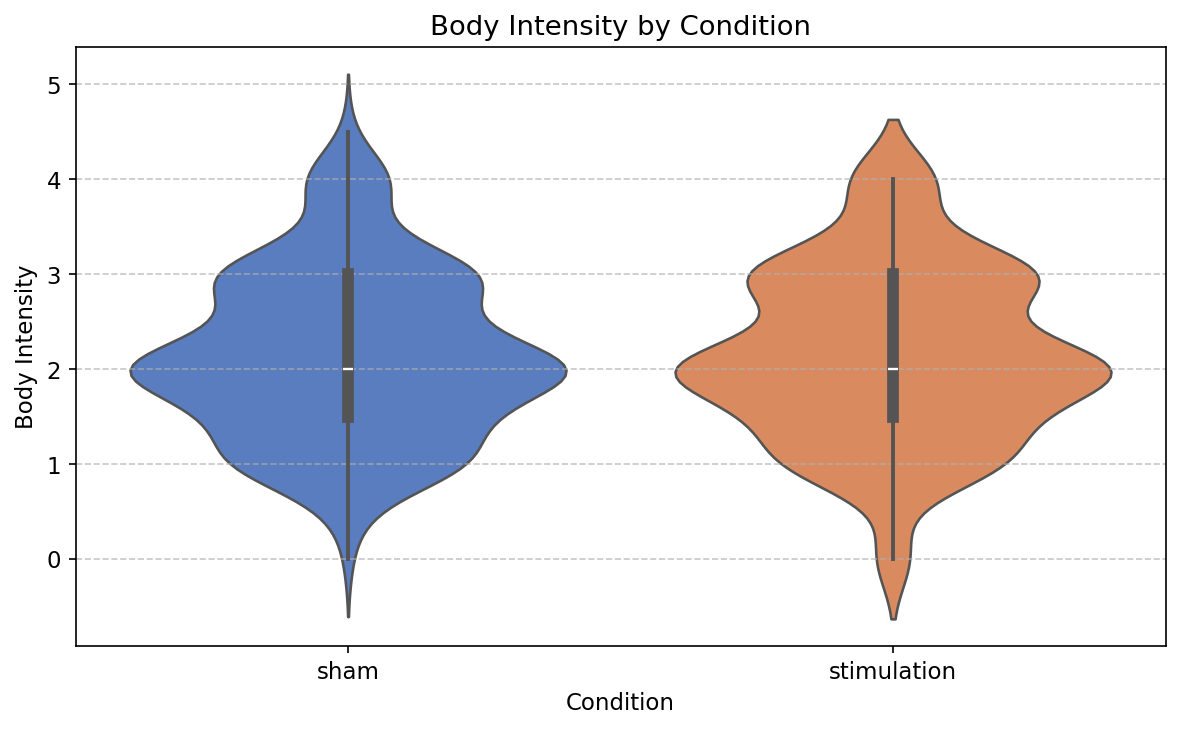

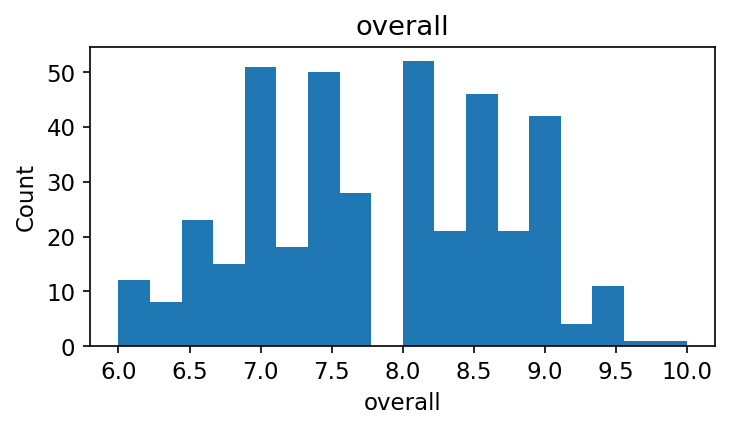

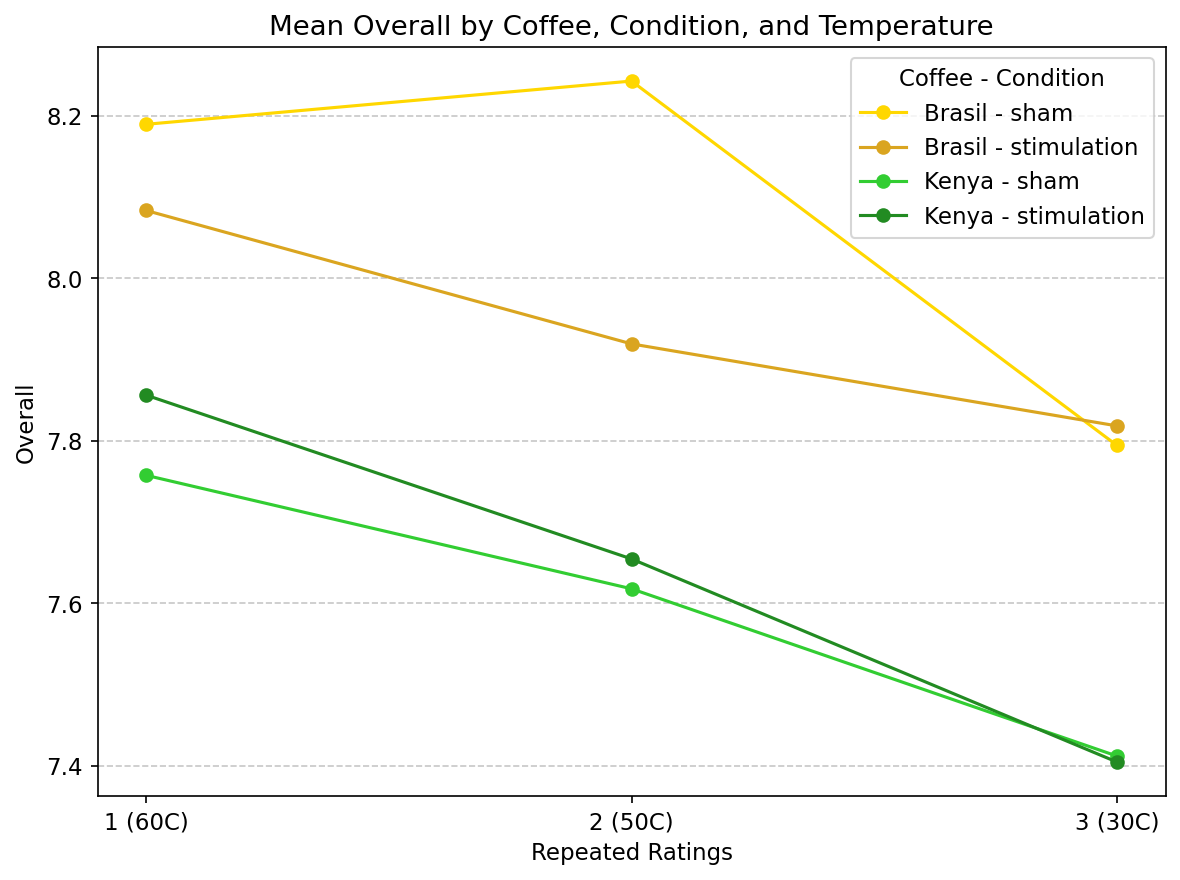

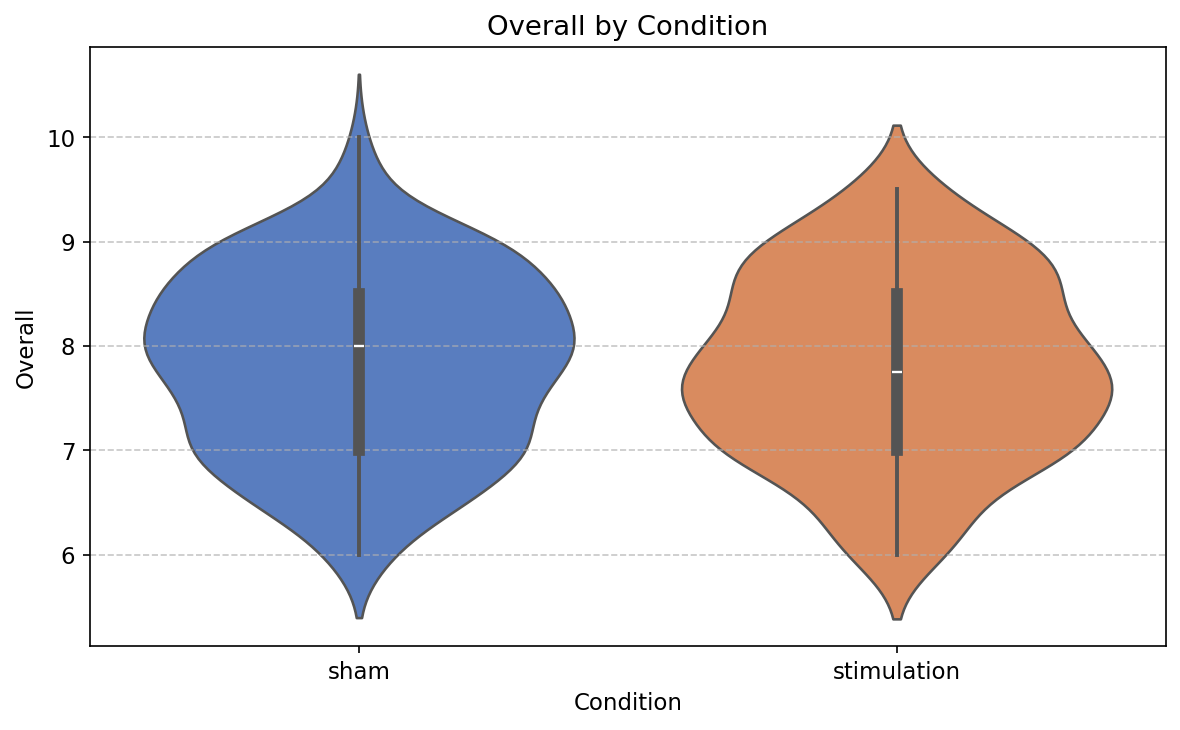

In [13]:
# ==============================================================================
# 5. EXPLORATORY VISUALISATION
# ==============================================================================
# Reusable plotting functions instead of copy-pasting a near-identical block
# per outcome. Call plot_outcome_trends() for whichever outcomes you want to
# inspect visually before/alongside modelling.

_COLOR_MAP = {
    ("Brasil", "sham"): "gold",
    ("Brasil", "stimulation"): "goldenrod",
    ("Kenya", "sham"): "limegreen",
    ("Kenya", "stimulation"): "forestgreen",
}


def plot_outcome_distribution(data: pd.DataFrame, outcome: str) -> None:
    """Histogram of raw responses for one outcome, to eyeball scale range,
    skew, and any obviously implausible values before modelling."""
    plt.figure(figsize=(5, 3))
    plt.hist(data[outcome].dropna(), bins=18)
    plt.title(outcome)
    plt.xlabel(outcome)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_outcome_trends(data: pd.DataFrame, outcome: str) -> None:
    """Mean outcome by coffee x condition across the three temperature
    ratings -- the same descriptive plot used for 'overall', 'acidity', and
    'balance' in the original notebook, generalised to any outcome column."""
    summary = (
        data.groupby(["coffee", "condition", "repeated_ratings"])[outcome]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 6))
    for (coffee_type, cond), grp in summary.groupby(["coffee", "condition"]):
        plt.plot(
            grp["repeated_ratings"], grp[outcome], marker="o",
            label=f"{coffee_type} - {cond}",
            color=_COLOR_MAP.get((coffee_type, cond)),
        )
    plt.legend(title="Coffee - Condition")
    plt.xlabel("Repeated Ratings")
    plt.ylabel(outcome.replace("_", " ").title())
    plt.xticks([1, 2, 3], ["1 (60C)", "2 (50C)", "3 (30C)"])
    plt.title(f"Mean {outcome.replace('_', ' ').title()} by Coffee, Condition, and Temperature")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_outcome_by_condition_violin(data: pd.DataFrame, outcome: str) -> None:
    """Violin plot of one outcome split by tDCS condition."""
    plt.figure(figsize=(8, 5))
    sns.violinplot(x="condition", y=outcome, data=data, palette="muted")
    plt.title(f"{outcome.replace('_', ' ').title()} by Condition")
    plt.xlabel("Condition")
    plt.ylabel(outcome.replace("_", " ").title())
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


# Outcomes you want to examine (matches your request: Flavour, Aftertaste,
# Acidity, Sweetness, Balance, Body, Acidity Intensity, Body Intensity,
# Overall hedonic liking). Only columns that actually exist in the data are used.
OUTCOMES_OF_INTEREST = [
    o for o in
    ["flavour", "aftertaste", "sweetness", "balance", "body",
     "acidity_intensity", "body_intensity", "overall"]
    if o in analysis_df.columns
]
print(f"\nOutcomes to be modelled: {OUTCOMES_OF_INTEREST}")

# Uncomment to generate exploratory plots for every outcome of interest.
# (Left off by default so the script doesn't pop out ~30 figures on import.)
#
for outcome in OUTCOMES_OF_INTEREST:
     plot_outcome_distribution(analysis_df, outcome)
     plot_outcome_trends(analysis_df, outcome)
     plot_outcome_by_condition_violin(analysis_df, outcome)

# 6. BAYESIAN MODEL DEFINITION

Hierarchical (multilevel) linear model, one outcome at a time:

 y_i ~ Normal(mu_i, sigma)

   mu_i = beta0
        + beta_stim * stim_i + beta_fam * fam_i
        + beta_warm * warm_i + beta_cold * cold_i
        + beta_stim_fam  * stim_i*fam_i
        + beta_stim_warm * stim_i*warm_i + beta_stim_cold * stim_i*cold_i
        + beta_fam_warm  * fam_i*warm_i  + beta_fam_cold  * fam_i*cold_i
        + beta_threeway_warm * stim_i*fam_i*warm_i
        + beta_threeway_cold * stim_i*fam_i*cold_i
        + u_subject[subject_i] + u_stim_subject[subject_i]*stim_i
        + v_coffee[coffee_i] + w_tasting[tasting_i]

   u_subject       ~ Normal(0, sigma_subject)       random intercept / subject
   u_stim_subject  ~ Normal(0, sigma_stim_subject)  random stim slope / subject
   v_coffee        ~ Normal(0, sigma_coffee)        random intercept / coffee batch
   w_tasting       ~ Normal(0, sigma_tasting)       random intercept / tasting episode

 Predictors are left unstandardised because they already have directly
 interpretable 0/1 coding (see glossary above).

In [8]:
import cmdstanpy
from cmdstanpy import CmdStanModel
import arviz as az

cmdstanpy.install_cmdstan()  # no-op if already installed
print("CmdStan version:", cmdstanpy.cmdstan_path())

CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.39.0
Download successful, file: /tmp/tmpdcq036dc
Extracting distribution
Unpacked download as cmdstan-2.39.0
Building version cmdstan-2.39.0, may take several minutes, depending on your system.
Installed cmdstan-2.39.0
Test model compilation
CmdStan version: /root/.cmdstan/cmdstan-2.39.0


In [9]:
STAN_MODEL_PATH = "ips_flavour_model.stan"

STAN_CODE = r"""
data {
    int<lower=1> N;
    int<lower=1> N_subjects;
    int<lower=1> N_coffee;
    int<lower=1> N_tasting;

    array[N] int<lower=1,upper=N_subjects> subject;
    array[N] int<lower=1,upper=N_coffee> coffee;
    array[N] int<lower=1,upper=N_tasting> tasting;

    array[N] int<lower=0,upper=1> stim;
    array[N] int<lower=0,upper=1> fam;
    array[N] int<lower=0,upper=1> temp_warm;
    array[N] int<lower=0,upper=1> temp_cold;

    vector[N] y;
}

parameters {
    real beta0;

    real beta_stim;
    real beta_fam;
    real beta_warm;
    real beta_cold;

    real beta_stim_fam;
    real beta_stim_warm;
    real beta_stim_cold;
    real beta_fam_warm;
    real beta_fam_cold;

    real beta_threeway_warm;
    real beta_threeway_cold;

    vector[N_subjects] z_subject;
    vector[N_coffee] z_coffee;
    vector[N_tasting] z_tasting;
    vector[N_subjects] z_stim_subject;

    real<lower=0> sigma_subject;
    real<lower=0> sigma_coffee;
    real<lower=1e-6> sigma_tasting;
    real<lower=0> sigma_stim_subject;
    real<lower=0> sigma;
}

transformed parameters {
    // Non-centred parameterisation: sample z ~ Normal(0,1) and scale, which
    // samples much more efficiently than sampling the random effects directly.
    vector[N_subjects] subject_effect = sigma_subject * z_subject;
    vector[N_subjects] stim_subject_effect = sigma_stim_subject * z_stim_subject;
    vector[N_coffee] coffee_effect = sigma_coffee * z_coffee;
    vector[N_tasting] tasting_effect = sigma_tasting * z_tasting;
}

model {
    // Weakly informative priors, centred on scale midpoint / no effect
    beta0 ~ normal(6.5, 1);

    beta_stim ~ normal(0, 0.5);
    beta_fam ~ normal(0, 0.5);
    beta_warm ~ normal(0, 0.5);
    beta_cold ~ normal(0, 0.5);

    beta_stim_fam ~ normal(0, 0.5);
    beta_stim_warm ~ normal(0, 0.5);
    beta_stim_cold ~ normal(0, 0.5);
    beta_fam_warm ~ normal(0, 0.5);
    beta_fam_cold ~ normal(0, 0.5);

    beta_threeway_warm ~ normal(0, 0.5);
    beta_threeway_cold ~ normal(0, 0.5);

    z_subject ~ normal(0, 1);
    z_stim_subject ~ normal(0, 1);
    z_coffee ~ normal(0, 1);
    z_tasting ~ normal(0, 1);

    sigma_subject ~ cauchy(0, 2.5);
    sigma_stim_subject ~ cauchy(0, 2.5);
    sigma_coffee ~ cauchy(0, 2.5);
    sigma_tasting ~ cauchy(0, 0.5);
    sigma ~ cauchy(0, 2.5);

    for (i in 1:N) {
        real mu =
            beta0
            + beta_stim * stim[i]
            + beta_fam * fam[i]
            + beta_warm * temp_warm[i]
            + beta_cold * temp_cold[i]
            + beta_stim_fam * stim[i] * fam[i]
            + beta_stim_warm * stim[i] * temp_warm[i]
            + beta_stim_cold * stim[i] * temp_cold[i]
            + beta_fam_warm * fam[i] * temp_warm[i]
            + beta_fam_cold * fam[i] * temp_cold[i]
            + beta_threeway_warm * stim[i] * fam[i] * temp_warm[i]
            + beta_threeway_cold * stim[i] * fam[i] * temp_cold[i]
            + subject_effect[subject[i]]
            + stim_subject_effect[subject[i]] * stim[i]
            + coffee_effect[coffee[i]]
            + tasting_effect[tasting[i]];

        y[i] ~ normal(mu, sigma);
    }
}

generated quantities {
    vector[N] y_rep;
    vector[N] log_lik;

    for (i in 1:N) {
        real mu =
            beta0
            + beta_stim * stim[i]
            + beta_fam * fam[i]
            + beta_warm * temp_warm[i]
            + beta_cold * temp_cold[i]
            + beta_stim_fam * stim[i] * fam[i]
            + beta_stim_warm * stim[i] * temp_warm[i]
            + beta_stim_cold * stim[i] * temp_cold[i]
            + beta_fam_warm * fam[i] * temp_warm[i]
            + beta_fam_cold * fam[i] * temp_cold[i]
            + beta_threeway_warm * stim[i] * fam[i] * temp_warm[i]
            + beta_threeway_cold * stim[i] * fam[i] * temp_cold[i]
            + subject_effect[subject[i]]
            + stim_subject_effect[subject[i]] * stim[i]
            + coffee_effect[coffee[i]]
            + tasting_effect[tasting[i]];

        y_rep[i] = normal_rng(mu, sigma);
        log_lik[i] = normal_lpdf(y[i] | mu, sigma);
    }
}
"""

with open(STAN_MODEL_PATH, "w") as f:
    f.write(STAN_CODE)
print(f"Stan model written to {STAN_MODEL_PATH}")

stan_model = CmdStanModel(stan_file=STAN_MODEL_PATH)  # compiled once, reused for every outcome

KEY_TERMS = [
    "beta_stim_fam", "beta_stim_warm", "beta_stim_cold",
    "beta_fam_warm", "beta_fam_cold",
    "beta_threeway_warm", "beta_threeway_cold",
    "sigma_subject", "sigma_stim_subject", "sigma_coffee", "sigma_tasting", "sigma",
]

Stan model written to ips_flavour_model.stan


In [14]:
# ==============================================================================
# 7. MODEL-FITTING PIPELINE (reused for every outcome)
# ==============================================================================

def build_model_df(outcome: str) -> pd.DataFrame:
    """Slice analysis_df down to the columns Stan needs for one outcome,
    and drop rows where that outcome is missing."""
    cols = ["participant_idx", "coffee_idx", "tasting_idx",
            "stim_idx", "fam_idx", "temp_warm", "temp_cold", outcome]
    return analysis_df[cols].dropna(subset=[outcome]).copy()


def build_stan_data(model_df: pd.DataFrame, outcome: str) -> dict:
    return {
        "N": len(model_df),
        "N_subjects": model_df["participant_idx"].nunique(),
        "N_coffee": model_df["coffee_idx"].nunique(),
        "N_tasting": model_df["tasting_idx"].nunique(),
        "subject": model_df["participant_idx"].values.tolist(),
        "coffee": model_df["coffee_idx"].values.tolist(),
        "tasting": model_df["tasting_idx"].values.tolist(),
        "stim": model_df["stim_idx"].values.tolist(),
        "fam": model_df["fam_idx"].values.tolist(),
        "temp_warm": model_df["temp_warm"].values.tolist(),
        "temp_cold": model_df["temp_cold"].values.tolist(),
        "y": model_df[outcome].values.tolist(),
    }


def fit_outcome_model(outcome: str):
    """Fit the hierarchical Bayesian model for a single outcome variable.
    Returns (fit, idata, model_df)."""
    print(f"\n{'=' * 60}\nFitting model for outcome: {outcome}\n{'=' * 60}")

    model_df = build_model_df(outcome)
    stan_data = build_stan_data(model_df, outcome)

    fit = stan_model.sample(
        data=stan_data,
        chains=1,               # use >1 chain for real inference; convergence
                                 # diagnostics (R-hat, ESS) need multiple chains
        iter_sampling=2000,
        iter_warmup=1000,
        seed=123,
        show_progress=True,
        adapt_delta=0.99,       # high adapt_delta + max_treedepth: this model
        max_treedepth=12,       # has several interaction/random-effect terms
                                 # and can need extra sampler care to avoid
                                 # divergences
    )

    # idata is built immediately -- everything downstream (posterior
    # extraction, trace/posterior plots) depends on it existing first.
    idata = az.from_cmdstanpy(fit)

    return fit, idata, model_df


In [15]:
# ==============================================================================
# 8. FIT ALL OUTCOMES OF INTEREST
# ==============================================================================
# This replaces the single hardcoded `OUTCOME = "balance"` from the original
# notebook. Each outcome gets its own independent model fit; results are
# collected below into one comparison table.
#
# IMPORTANT -- multiple comparisons: running the same hypothesis test across
# 9 outcomes inflates the false-positive rate if you treat each P(beta>0) as
# a stand-alone significance test. At minimum, report all 9 results together
# (not just the ones that "worked") and treat any single outcome's result as
# provisional until it either (a) replicates across related outcomes, or
# (b) is re-tested in a joint multivariate model (see Section 10).

results = {}  # outcome -> {"fit":, "idata":, "model_df":}

for outcome in OUTCOMES_OF_INTEREST:
    try:
        fit, idata, model_df = fit_outcome_model(outcome)
        results[outcome] = {"fit": fit, "idata": idata, "model_df": model_df}
    except ValueError as e:
        print(f"\n{'!' * 60}\nERROR: Model fitting failed for outcome: {outcome}\n{'!' * 60}")
        print(f"Error details: {e}")
        if 'fit' in locals() and hasattr(fit, 'runset') and fit.runset.get_err_msgs():
            for msg in fit.runset.get_err_msgs():
                print(f"CmdStan error message: {msg}")
        print("Skipping this outcome and continuing with others.")
        continue



Fitting model for outcome: flavour


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

	Chain 1 had 3 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



Fitting model for outcome: aftertaste


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

                                                                                

Fitting model for outcome: body_intensity


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


RuntimeError: Error during sampling:
Exception: ips_flavour_model_model_namespace::ips_flavour_model_model: tasting[386] is 136, but must be less than or equal to 134.000000 (in 'ips_flavour_model.stan', line 10, column 4 to column 50)
Command and output files:
RunSet: chains=1, chain_ids=[1], num_processes=1
 cmd (chain 1):
	['/content/ips_flavour_model', 'id=1', 'random', 'seed=123', 'data', 'file=/tmp/tmp07qxepaq/8qnjwio5.json', 'output', 'file=/tmp/tmp07qxepaq/ips_flavour_model56e8bk3r/ips_flavour_model-20260803205349.csv', 'method=sample', 'num_samples=2000', 'num_warmup=1000', 'algorithm=hmc', 'engine=nuts', 'max_depth=12', 'adapt', 'engaged=1', 'delta=0.99']
 retcodes=[1]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmp07qxepaq/ips_flavour_model56e8bk3r/ips_flavour_model-20260803205349.csv
 console_msgs (if any):
	/tmp/tmp07qxepaq/ips_flavour_model56e8bk3r/ips_flavour_model-20260803205349_0-stdout.txt
Consider re-running with show_console=True if the above ou

In [ ]:
# ==============================================================================
# 9. COMPARISON TABLE ACROSS OUTCOMES
# ==============================================================================
# Posterior mean / 95% credible interval for each key interaction term,
# one row per outcome -- lets you scan all 9 outcomes at once instead of
# re-running the notebook per outcome.

comparison_rows = []
for outcome, res in results.items():
    summary = res["fit"].summary()
    for term in KEY_TERMS:
        if term not in summary.index:
            continue
        row = summary.loc[term]
        comparison_rows.append({
            "outcome": outcome,
            "term": term,
            "mean": row["Mean"],
            "sd": row["StdDev"],
            "q5": row["5%"],
            "q95": row["95%"],
            "r_hat": row.get("R_hat", np.nan),
        })

comparison_table = pd.DataFrame(comparison_rows)
print("\nComparison of key effects across all outcomes:")
print(comparison_table)

# Flag any parameter with R-hat > 1.01 -- standard convergence red flag
poor_convergence = comparison_table[comparison_table["r_hat"] > 1.01]
if not poor_convergence.empty:
    print("\nWARNING -- possible non-convergence (R-hat > 1.01):")
    print(poor_convergence)

In [ ]:
# ==============================================================================
# 10. POSTERIOR PREDICTIONS AND CONTRASTS (per outcome)
# ==============================================================================

def posterior_prediction(posterior, stim: int, fam: int, warm: int, cold: int):
    """Predicted mean rating (on the posterior draw level) for a given
    combination of stimulation / familiarity / temperature, using the
    fixed-effects part of the model (population-level prediction, i.e.
    marginalised over subject/coffee/tasting random effects)."""
    return (
        posterior["beta0"]
        + posterior["beta_stim"] * stim
        + posterior["beta_fam"] * fam
        + posterior["beta_warm"] * warm
        + posterior["beta_cold"] * cold
        + posterior["beta_stim_fam"] * stim * fam
        + posterior["beta_stim_warm"] * stim * warm
        + posterior["beta_stim_cold"] * stim * cold
        + posterior["beta_fam_warm"] * fam * warm
        + posterior["beta_fam_cold"] * fam * cold
        + posterior["beta_threeway_warm"] * stim * fam * warm
        + posterior["beta_threeway_cold"] * stim * fam * cold
    )


# (Stim, Fam, Temp label) -> (stim, fam, warm, cold) dummy coding
CONDITIONS = [
    ("Sham", "Brazil", "Hot", 0, 0, 0, 0),
    ("Sham", "Brazil", "Warm", 0, 0, 1, 0),
    ("Sham", "Brazil", "Cold", 0, 0, 0, 1),
    ("Sham", "Kenya", "Hot", 0, 1, 0, 0),
    ("Sham", "Kenya", "Warm", 0, 1, 1, 0),
    ("Sham", "Kenya", "Cold", 0, 1, 0, 1),
    ("Stim", "Brazil", "Hot", 1, 0, 0, 0),
    ("Stim", "Brazil", "Warm", 1, 0, 1, 0),
    ("Stim", "Brazil", "Cold", 1, 0, 0, 1),
    ("Stim", "Kenya", "Hot", 1, 1, 0, 0),
    ("Stim", "Kenya", "Warm", 1, 1, 1, 0),
    ("Stim", "Kenya", "Cold", 1, 1, 0, 1),
]


def estimated_marginal_means(idata) -> pd.DataFrame:
    """Predicted mean +/- 95% credible interval for all 12 stim x coffee x
    temperature cells, for one outcome's fitted model."""
    posterior = az.extract(idata)
    rows = []
    for cond_label, coffee_label, temp_label, stim, fam, warm, cold in CONDITIONS:
        draws = posterior_prediction(posterior, stim, fam, warm, cold)
        rows.append({
            "Condition": cond_label,
            "Coffee": coffee_label,
            "Temperature": temp_label,
            "Mean": float(draws.mean()),
            "Lower95": float(draws.quantile(0.025)),
            "Upper95": float(draws.quantile(0.975)),
        })
    return pd.DataFrame(rows)


def plot_estimated_marginal_means(emm: pd.DataFrame, outcome: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    temps = ["Hot", "Warm", "Cold"]
    x = np.arange(3)
    for condition in ["Sham", "Stim"]:
        for coffee in ["Brazil", "Kenya"]:
            subset = emm[(emm.Condition == condition) & (emm.Coffee == coffee)]
            ax.errorbar(
                x, subset["Mean"],
                yerr=[subset["Mean"] - subset["Lower95"], subset["Upper95"] - subset["Mean"]],
                marker="o", capsize=4, label=f"{condition} | {coffee}",
            )
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(temps)
    ax.set_ylabel(f"Predicted {outcome}")
    ax.set_title(f"Estimated marginal means: {outcome}")
    ax.legend()
    plt.tight_layout()
    plt.show()


def stim_x_familiarity_contrast(idata, temp_label: str = "cold") -> dict:
    """Posterior for the key H1/H3 contrast: does the stimulation effect
    (active - sham) differ between Brazil (familiar) and Kenya (unfamiliar)
    at a given temperature? Returns mean, 95% CrI, and P(contrast > 0)."""
    posterior = az.extract(idata)
    warm, cold = (1, 0) if temp_label == "warm" else (0, 1) if temp_label == "cold" else (0, 0)

    stim_brazil = posterior_prediction(posterior, 1, 0, warm, cold)
    sham_brazil = posterior_prediction(posterior, 0, 0, warm, cold)
    stim_kenya = posterior_prediction(posterior, 1, 1, warm, cold)
    sham_kenya = posterior_prediction(posterior, 0, 1, warm, cold)

    contrast = (stim_brazil - sham_brazil) - (stim_kenya - sham_kenya)
    return {
        "temperature": temp_label,
        "mean": float(contrast.mean()),
        "ci_low": float(np.quantile(contrast, 0.025)),
        "ci_high": float(np.quantile(contrast, 0.975)),
        "p_gt_0": float(np.mean(contrast > 0)),
    }


contrast_rows = []
for outcome, res in results.items():
    emm = estimated_marginal_means(res["idata"])
    # Uncomment to render the EMM plot for every outcome:
    # plot_estimated_marginal_means(emm, outcome)

    for temp_label in ["hot", "warm", "cold"]:
        c = stim_x_familiarity_contrast(res["idata"], temp_label=temp_label)
        c["outcome"] = outcome
        contrast_rows.append(c)

contrast_table = pd.DataFrame(contrast_rows)[
    ["outcome", "temperature", "mean", "ci_low", "ci_high", "p_gt_0"]
]
print("\nStimulation x Familiarity contrast, by outcome and temperature:")
print(contrast_table)

In [ ]:
# 11. MCMC DIAGNOSTICS (per outcome)
# ==============================================================================
# Always check trace/posterior plots and R-hat before interpreting effects --
# not shown by default here to avoid rendering ~20 figures per run.

def plot_diagnostics(idata, outcome: str) -> None:
    az.plot_trace(idata, var_names=["sigma"])
    plt.suptitle(f"Trace plot for sigma ({outcome})", y=1.02)
    plt.tight_layout()
    plt.show()

    az.plot_trace(idata, var_names=["beta_stim_fam", "beta_threeway_cold"])
    plt.suptitle(f"Trace plots for key interaction terms ({outcome})", y=1.02)
    plt.tight_layout()
    plt.show()

    az.plot_posterior(idata, var_names=["beta_stim_fam", "beta_threeway_cold"])
    plt.suptitle(f"Posterior plots for key interaction terms ({outcome})", y=1.02)
    plt.tight_layout()
    plt.show()

# Example: check diagnostics for a single outcome
# plot_diagnostics(results["balance"]["idata"], "balance")


# ==============================================================================
# NOTES FOR NEXT ITERATION (alternative analysis approaches)
# ==============================================================================
# 1. Joint multivariate model: instead of looping 9 separate univariate
#    models, model all outcomes simultaneously with a multivariate normal
#    likelihood (vector y_i in R^9, residual covariance matrix Sigma). This
#    (a) borrows statistical strength across correlated rating scales,
#    (b) gives one coherent multiple-comparisons-adjusted answer instead of
#    9 separate tests, and (c) lets you directly ask "does stimulation shift
#    a *general* flavour-perception factor, or only specific attributes?"
# 2. Ordinal/bounded-scale likelihood: if the rating scales are bounded
#    Likert/VAS scores rather than approximately continuous/unbounded, an
#    ordered-logistic or Beta likelihood may fit the data-generating process
#    better than Normal.
# 3. Model comparison: use `log_lik` (already saved in generated quantities)
#    with `az.loo()` to compare this model against simpler alternatives
#    (e.g. dropping the three-way interaction) via PSIS-LOO.
# 4. Re-derive the "overall < 6 = error" rule from your protocol notes rather
#    than a fixed threshold, and consider whether it should apply to other
#    outcomes too.
# ==============================================================================

print("\nDone. See `results`, `comparison_table`, and `contrast_table` for output.")


Environment loaded.
